In [1]:
%load_ext autoreload
%autoreload 2


# Trading Competition Training

Train Nash-DQN and locally linear-quadratic SRE-DQN on the shared trading competition environment.

In [2]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root(start):
    start = Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / 'AGENTS.md').exists() and (path / 'continuous_action_space').exists():
            return path
    raise RuntimeError('Could not locate repo root')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

EXPERIMENT_DIR = REPO_ROOT / 'continuous_action_space' / 'trading_competition'
MODEL_ROOT = EXPERIMENT_DIR / 'pt_files'
MODEL_ROOT.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=4)
print('Repo root:', REPO_ROOT)
print('Model root:', MODEL_ROOT)
print('Using device:', 'cuda' if torch.cuda.is_available() else 'cpu')


Repo root: /home/wowthecoder/SRE-DQN
Model root: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files
Using device: cuda


## Imports And Helpers


In [3]:
from continuous_action_space.trading_competition.experiment_config import (
    NUM_PLAYERS as num_players,
    sim_dict,
    norm_mean,
    norm_std,
    T,
    make_sim_obj,
    seed_everything,
    configure_torch_gpu_math,
    eps_slug,
    seed_slug,
    BASE_SEED,
    MAX_STEPS,
    LLQ_SRE_EPS_LIST,
    SRE_EPS_REG,
    SRE_DELTA_MIN,
    SRE_GAMMA,
    NET_KWARGS,
)
from continuous_action_space.trading_competition.training import run_training_loop
from continuous_action_space.locally_linear_quadratic.NashAgent_lib import NashNN
from continuous_action_space.locally_linear_quadratic.sre_agent import SreNN

configure_torch_gpu_math()
sim_obj = make_sim_obj()


def make_nash_action(agent, eps_b, noise_std):
    del eps_b
    def fn(cur_s, cur_ivt):
        mu = agent.predict_action(cur_s, cur_ivt)[:, 4]
        return mu + torch.randn_like(mu) * noise_std
    return fn


def make_llq_sre_action(agent, eps_b, noise_std):
    def fn(cur_s, cur_ivt):
        mu_sr = agent.compute_sre_action(cur_s, cur_ivt, eps_b)
        return mu_sr + torch.randn_like(mu_sr) * noise_std
    return fn


def make_eps_schedule(eps_0):
    def eps_schedule(k, num_sim):
        if SRE_EPS_DECAY is None:
            return eps_0
        return eps_0 * max(0.0, 1.0 - k / max(SRE_EPS_DECAY, 1))
    return eps_schedule


print('Agents:', num_players, '| T=', sim_dict['T'].item(), '| dt=', sim_dict['dt'].item(), '| impact=', sim_obj.impact)

Agents: 5 | T= 5 | dt= 0.5 | impact= sqrt


## Training Configuration


In [4]:
NASH_SEED = BASE_SEED
LLQ_SRE_TRAIN_SEED = BASE_SEED

NUM_SIM = 10000
RV_MIN = 0.5
RV_MAX = 2.5
EARLY_STOP = True
EARLY_LIM = 3000
MINI_BATCH = 128
SRE_EPS_DECAY = None

TRAINING_LOG_KWARGS = dict(
    loss_log_every=1000,
    log_best_updates=False,
    log_weight_saves=False,
)

NASH_RUN_TAG = seed_slug(NASH_SEED)
LLQ_SRE_RUN_TAG = seed_slug(LLQ_SRE_TRAIN_SEED)

NASH_MODEL_DIR = MODEL_ROOT / f'nash_{NASH_RUN_TAG}'
LLQ_SRE_MODEL_DIRS = {
    eps: MODEL_ROOT / f'llq_sre_eps_{eps_slug(eps)}_{LLQ_SRE_RUN_TAG}'
    for eps in LLQ_SRE_EPS_LIST
}

seed_everything(BASE_SEED)
print('NUM_SIM:', NUM_SIM, '| MAX_STEPS:', MAX_STEPS, '| MINI_BATCH:', MINI_BATCH)
print('LLQ Epsilon sweep:', LLQ_SRE_EPS_LIST, '| decay horizon:', SRE_EPS_DECAY)
print('Nash dir:', NASH_MODEL_DIR)

NUM_SIM: 10000 | MAX_STEPS: 10 | MINI_BATCH: 128
LLQ Epsilon sweep: [0.0, 0.01, 0.1, 0.5, 1.0] | decay horizon: None
Nash dir: /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/nash_seed_20260409


## Train Nash-DQN


In [5]:
nash_agent = None
nash_loss = None
nash_train_time = None

NASH_MODEL_DIR.mkdir(parents=True, exist_ok=True)
seed_everything(NASH_SEED)
nash_agent = NashNN(**NET_KWARGS)
start = time.time()
nash_agent, nash_loss = run_training_loop(
    sim_obj=sim_obj,
    sim_dict=sim_dict,
    max_steps=MAX_STEPS,
    agent=nash_agent,
    make_action_fn=make_nash_action,
    eps_schedule_fn=None,
    num_sim=NUM_SIM,
    norm_mean=norm_mean,
    norm_std=norm_std,
    rv_min=RV_MIN,
    rv_max=RV_MAX,
    early_stop=EARLY_STOP,
    early_lim=EARLY_LIM,
    mini_batch=MINI_BATCH,
    path=str(NASH_MODEL_DIR),
    AN_file_name=str(NASH_MODEL_DIR / 'Action_Net'),
    VN_file_name=str(NASH_MODEL_DIR / 'Value_Net'),
    checkpoint_metadata={'trainer': 'nash_dqn', 'seed': int(NASH_SEED)},
    desc='Nash-DQN',
    **TRAINING_LOG_KWARGS,
)
nash_train_time = time.time() - start
print(f'Nash-DQN training time: {nash_train_time:.1f}s')


CUDA IS AVAILABLE!


Nash-DQN:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/wowthecoder/SRE-DQN/continuous_action_space/locally_linear_quadratic/NashAgent_lib.py:149: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ids = torch.tensor(torch.arange(self.num_players)).tile(num_entries).cuda()


Nash-DQN Episode 1000 | Total Loss 3651.0918 | V_loss 1831.0972 | A_loss 1819.9946
Nash-DQN Best so far | Episode 897 | Loss 2708.7666
Nash-DQN Episode 2000 | Total Loss 1134.9611 | V_loss 567.9925 | A_loss 566.9686
Nash-DQN Best so far | Episode 1753 | Loss 941.6228
Nash-DQN Episode 3000 | Total Loss 1426.3586 | V_loss 714.0351 | A_loss 712.3236
Nash-DQN Best so far | Episode 2036 | Loss 919.6309
Nash-DQN Episode 4000 | Total Loss 1387.4772 | V_loss 694.2632 | A_loss 693.2140
Nash-DQN Best so far | Episode 2036 | Loss 919.6309
Nash-DQN Episode 5000 | Total Loss 1470.7134 | V_loss 736.1970 | A_loss 734.5163
Nash-DQN Best so far | Episode 2036 | Loss 919.6309
EARLY STOPPING at episode 5037
Latest best checkpoint remains in /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/nash_seed_20260409/best_checkpoint
Nash-DQN training time: 280.8s


## Train Locally Linear-Quadratic SRE-DQN


In [6]:
llq_sre_agents = {}
llq_sre_losses = {}
llq_sre_train_times = {}

for eps in LLQ_SRE_EPS_LIST:
    eps_dir = LLQ_SRE_MODEL_DIRS[eps]
    eps_dir.mkdir(parents=True, exist_ok=True)

    seed_everything(LLQ_SRE_TRAIN_SEED)
    sre_agent = SreNN(
        **NET_KWARGS,
        eps_reg=SRE_EPS_REG,
        delta_min=SRE_DELTA_MIN,
        gamma=SRE_GAMMA,
    )

    start = time.time()
    trained_agent, train_loss = run_training_loop(
        sim_obj=sim_obj,
        sim_dict=sim_dict,
        max_steps=MAX_STEPS,
        agent=sre_agent,
        make_action_fn=make_llq_sre_action,
        eps_schedule_fn=make_eps_schedule(eps),
        num_sim=NUM_SIM,
        norm_mean=norm_mean,
        norm_std=norm_std,
        rv_min=RV_MIN,
        rv_max=RV_MAX,
        early_stop=EARLY_STOP,
        early_lim=EARLY_LIM,
        mini_batch=MINI_BATCH,
        path=str(eps_dir),
        AN_file_name=str(eps_dir / f'LLQ_SRE_Action_Net_eps_{eps_slug(eps)}'),
        VN_file_name=str(eps_dir / f'LLQ_SRE_Value_Net_eps_{eps_slug(eps)}'),
        checkpoint_metadata={
            'trainer': 'llq_sre_dqn',
            'seed': int(LLQ_SRE_TRAIN_SEED),
            'eps_0': float(eps),
            'eps_decay_horizon': None if SRE_EPS_DECAY is None else int(SRE_EPS_DECAY),
            'eps_reg': float(SRE_EPS_REG),
            'delta_min': float(SRE_DELTA_MIN),
            'gamma': float(SRE_GAMMA),
        },
        desc=f'LLQ SRE-DQN eps={eps:g}',
        **TRAINING_LOG_KWARGS,
    )
    llq_sre_agents[eps] = trained_agent
    llq_sre_losses[eps] = train_loss
    llq_sre_train_times[eps] = time.time() - start
    print(f'LLQ SRE-DQN training time (eps={eps:g}): {llq_sre_train_times[eps]:.1f}s')


CUDA IS AVAILABLE!


LLQ SRE-DQN eps=0:   0%|          | 0/10000 [00:00<?, ?it/s]

LLQ SRE-DQN eps=0 Episode 1000 | Total Loss 3654.7595 | V_loss 1832.2721 | A_loss 1822.4874
LLQ SRE-DQN eps=0 Best so far | Episode 897 | Loss 2710.4819
LLQ SRE-DQN eps=0 Episode 2000 | Total Loss 1117.2957 | V_loss 558.8004 | A_loss 558.4953
LLQ SRE-DQN eps=0 Best so far | Episode 1672 | Loss 936.2454
LLQ SRE-DQN eps=0 Episode 3000 | Total Loss 1433.8396 | V_loss 717.9794 | A_loss 715.8602
LLQ SRE-DQN eps=0 Best so far | Episode 2036 | Loss 891.9045
LLQ SRE-DQN eps=0 Episode 4000 | Total Loss 1388.4680 | V_loss 694.8458 | A_loss 693.6223
LLQ SRE-DQN eps=0 Best so far | Episode 2036 | Loss 891.9045
LLQ SRE-DQN eps=0 Episode 5000 | Total Loss 1466.1772 | V_loss 733.8859 | A_loss 732.2913
LLQ SRE-DQN eps=0 Best so far | Episode 2036 | Loss 891.9045
EARLY STOPPING at episode 5037
Latest best checkpoint remains in /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_0_seed_20260409/best_checkpoint
LLQ SRE-DQN training time (eps=0): 358.9s
CUDA IS AVAIL

LLQ SRE-DQN eps=0.01:   0%|          | 0/10000 [00:00<?, ?it/s]

LLQ SRE-DQN eps=0.01 Episode 1000 | Total Loss 3672.4512 | V_loss 1840.2407 | A_loss 1832.2103
LLQ SRE-DQN eps=0.01 Best so far | Episode 897 | Loss 2701.0305
LLQ SRE-DQN eps=0.01 Episode 2000 | Total Loss 1113.4309 | V_loss 557.0544 | A_loss 556.3764
LLQ SRE-DQN eps=0.01 Best so far | Episode 1672 | Loss 921.4835
LLQ SRE-DQN eps=0.01 Episode 3000 | Total Loss 1425.5607 | V_loss 713.6780 | A_loss 711.8827
LLQ SRE-DQN eps=0.01 Best so far | Episode 2036 | Loss 896.0034
LLQ SRE-DQN eps=0.01 Episode 4000 | Total Loss 1389.5551 | V_loss 695.2032 | A_loss 694.3519
LLQ SRE-DQN eps=0.01 Best so far | Episode 2036 | Loss 896.0034
LLQ SRE-DQN eps=0.01 Episode 5000 | Total Loss 1463.0535 | V_loss 732.2823 | A_loss 730.7712
LLQ SRE-DQN eps=0.01 Best so far | Episode 2036 | Loss 896.0034
EARLY STOPPING at episode 5037
Latest best checkpoint remains in /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_0p01_seed_20260409/best_checkpoint
LLQ SRE-DQN training t

...

LLQ SRE-DQN eps=0.1 Episode 1000 | Total Loss 3699.7305 | V_loss 1853.8615 | A_loss 1845.8690
LLQ SRE-DQN eps=0.1 Best so far | Episode 897 | Loss 2743.3438
LLQ SRE-DQN eps=0.1 Episode 2000 | Total Loss 1145.1279 | V_loss 572.9478 | A_loss 572.1802
LLQ SRE-DQN eps=0.1 Best so far | Episode 1753 | Loss 925.0045
LLQ SRE-DQN eps=0.1 Episode 3000 | Total Loss 1399.3413 | V_loss 700.6010 | A_loss 698.7403
LLQ SRE-DQN eps=0.1 Best so far | Episode 1753 | Loss 925.0045
LLQ SRE-DQN eps=0.1 Episode 4000 | Total Loss 1364.2556 | V_loss 682.6480 | A_loss 681.6076
LLQ SRE-DQN eps=0.1 Best so far | Episode 1753 | Loss 925.0045
EARLY STOPPING at episode 4754
Latest best checkpoint remains in /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_0p1_seed_20260409/best_checkpoint
LLQ SRE-DQN training time (eps=0.1): 334.0s
CUDA IS AVAILABLE!


LLQ SRE-DQN eps=0.5:   0%|          | 0/10000 [00:00<?, ?it/s]

LLQ SRE-DQN eps=0.5 Episode 1000 | Total Loss 3782.0713 | V_loss 1902.7499 | A_loss 1879.3213
LLQ SRE-DQN eps=0.5 Best so far | Episode 996 | Loss 2837.3132
LLQ SRE-DQN eps=0.5 Episode 2000 | Total Loss 1046.3020 | V_loss 523.2598 | A_loss 523.0421
LLQ SRE-DQN eps=0.5 Best so far | Episode 1753 | Loss 948.2688
LLQ SRE-DQN eps=0.5 Episode 3000 | Total Loss 1322.4098 | V_loss 661.9833 | A_loss 660.4265
LLQ SRE-DQN eps=0.5 Best so far | Episode 2036 | Loss 827.0374
LLQ SRE-DQN eps=0.5 Episode 4000 | Total Loss 1271.5948 | V_loss 636.4830 | A_loss 635.1118
LLQ SRE-DQN eps=0.5 Best so far | Episode 2036 | Loss 827.0374
LLQ SRE-DQN eps=0.5 Episode 5000 | Total Loss 1320.9155 | V_loss 660.7983 | A_loss 660.1172
LLQ SRE-DQN eps=0.5 Best so far | Episode 2036 | Loss 827.0374
EARLY STOPPING at episode 5037
Latest best checkpoint remains in /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/llq_sre_eps_0p5_seed_20260409/best_checkpoint
LLQ SRE-DQN training time (eps=0.

LLQ SRE-DQN eps=1:   0%|          | 0/10000 [00:00<?, ?it/s]

RESETTING WEIGHTS
LLQ SRE-DQN eps=1 Episode 1000 | Total Loss 1861855.8750 | V_loss 931530.1875 | A_loss 930325.6875
LLQ SRE-DQN eps=1 Best so far | Episode 639 | Loss 19830.7539
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
LLQ SRE-DQN eps=1 Episode 2000 | Total Loss 147705.7812 | V_loss 74585.8047 | A_loss 73119.9688
LLQ SRE-DQN eps=1 Best so far | Episode 639 | Loss 19830.7539
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGHTS
RESETTING WEIGH

## Loss Curves


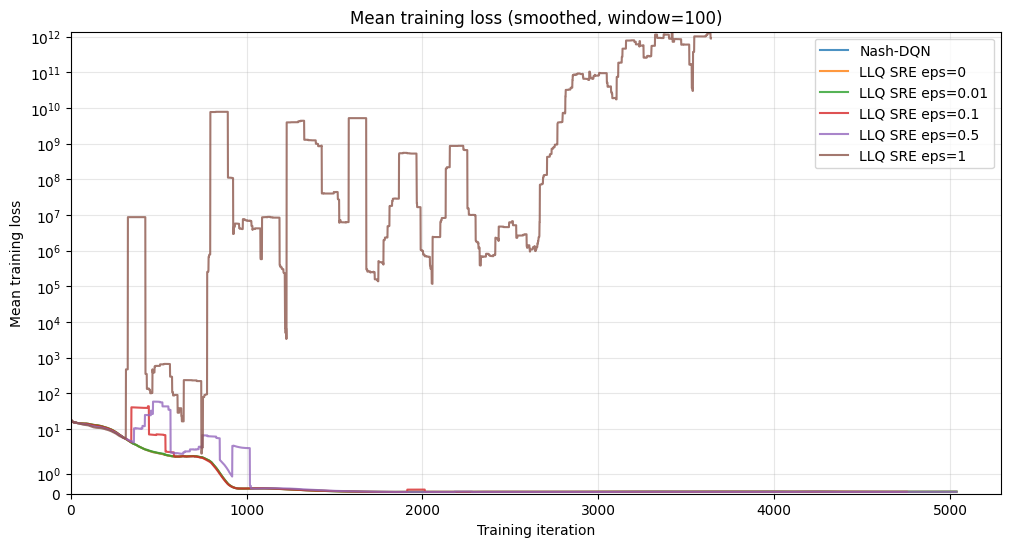

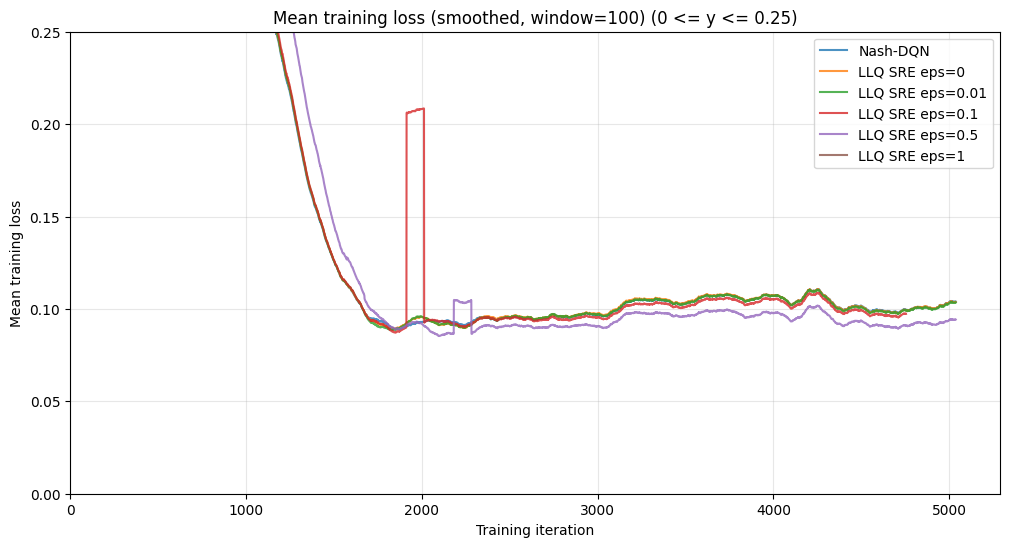

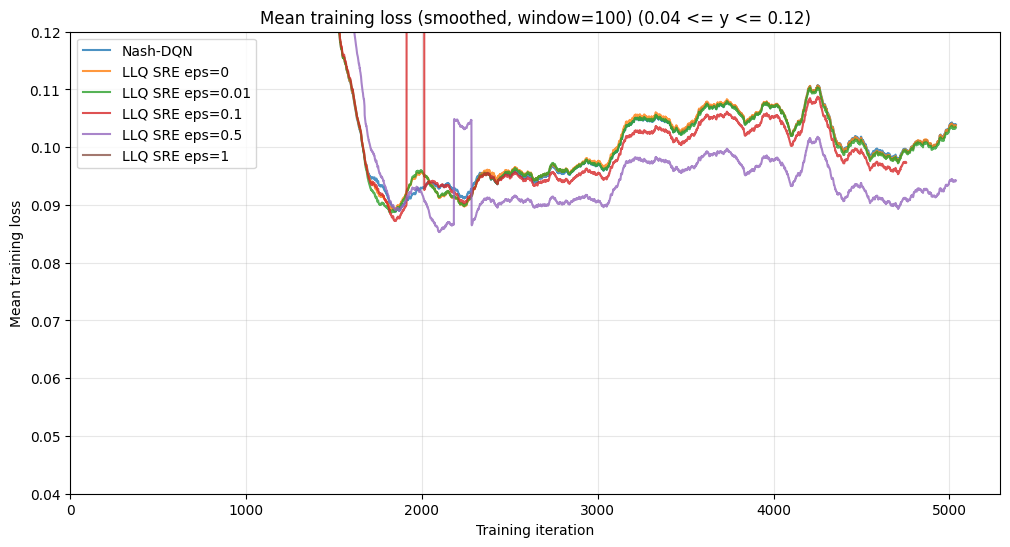

Saved loss plots:
  /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/training_mean_loss_sweep_seed_20260409_smoothed.png
  /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/training_mean_loss_sweep_seed_20260409_smoothed_y0_0p25.png
  /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/training_mean_loss_sweep_seed_20260409_smoothed_y0p04_0p12.png


In [7]:
SMOOTH_WINDOW = 100
LOSS_FIGURE_SEED_TAG = seed_slug(BASE_SEED)
LOSS_NORMALIZER = 2 * MINI_BATCH * MAX_STEPS * sim_obj.N
LOSS_SWEEP_PATH = MODEL_ROOT / f'training_mean_loss_sweep_{LOSS_FIGURE_SEED_TAG}_smoothed.png'
LOSS_SWEEP_CLIPPED_PATH = MODEL_ROOT / f'training_mean_loss_sweep_{LOSS_FIGURE_SEED_TAG}_smoothed_y0_0p25.png'
LOSS_SWEEP_ZOOM_PATH = MODEL_ROOT / f'training_mean_loss_sweep_{LOSS_FIGURE_SEED_TAG}_smoothed_y0p04_0p12.png'

def trim_loss_padding(loss):
    loss = list(loss)
    while len(loss) > 1 and loss[-1] == 0:
        loss.pop()
    return loss

def mean_loss(loss):
    return [value / LOSS_NORMALIZER for value in trim_loss_padding(loss)]

def smooth_loss(loss, window=SMOOTH_WINDOW):
    loss = mean_loss(loss)
    if window <= 1 or len(loss) <= 1:
        return loss
    smoothed = []
    running_sum = 0.0
    for idx, value in enumerate(loss):
        running_sum += value
        if idx >= window:
            running_sum -= loss[idx - window]
        current_window = min(idx + 1, window)
        smoothed.append(running_sum / current_window)
    return smoothed

def plot_loss_sweep(output_path, y_limits=None, use_symlog=False, title_suffix=''):
    fig = plt.figure(figsize=(12, 6))
    if nash_loss is not None:
        plt.plot(smooth_loss(nash_loss), label='Nash-DQN', alpha=0.8)
    for eps, loss in llq_sre_losses.items():
        plt.plot(smooth_loss(loss), label=f'LLQ SRE eps={eps:g}', alpha=0.8)
    plt.xlim(left=0)
    plt.margins(x=0)
    if use_symlog:
        plt.yscale('symlog')
    if y_limits is None:
        plt.ylim(bottom=0)
    else:
        plt.ylim(*y_limits)
    title = f'Mean training loss (smoothed, window={SMOOTH_WINDOW})'
    if title_suffix:
        title = f'{title} {title_suffix}'
    plt.title(title)
    plt.xlabel('Training iteration')
    plt.ylabel('Mean training loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_loss_sweep(LOSS_SWEEP_PATH, use_symlog=True)
plot_loss_sweep(LOSS_SWEEP_CLIPPED_PATH, y_limits=(0, 0.25), title_suffix='(0 <= y <= 0.25)')
plot_loss_sweep(LOSS_SWEEP_ZOOM_PATH, y_limits=(0.04, 0.12), title_suffix='(0.04 <= y <= 0.12)')

print('Saved loss plots:')
print(' ', LOSS_SWEEP_PATH)
print(' ', LOSS_SWEEP_CLIPPED_PATH)
print(' ', LOSS_SWEEP_ZOOM_PATH)

## Training reward curve


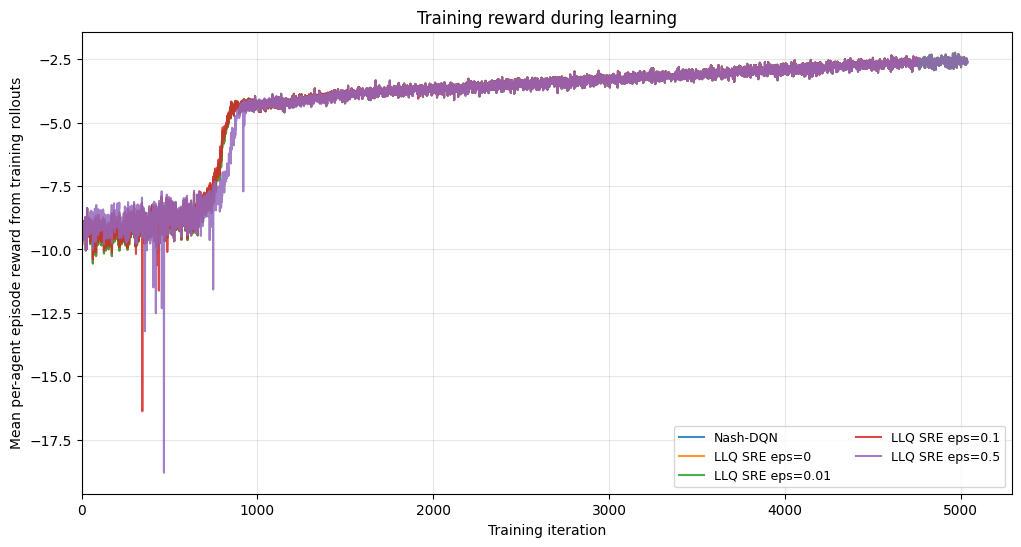

Saved training reward plot:
  /home/wowthecoder/SRE-DQN/continuous_action_space/trading_competition/pt_files/training_reward_during_training_seed_20260409.png


In [8]:
TRAINING_REWARD_PATH = MODEL_ROOT / f'training_reward_during_training_{LOSS_FIGURE_SEED_TAG}.png'

def checkpoint_training_history(model_dir):
    checkpoint_path = Path(model_dir) / 'final_checkpoint' / 'checkpoint.pt'
    if not checkpoint_path.exists():
        checkpoint_path = Path(model_dir) / 'best_checkpoint' / 'checkpoint.pt'
    if not checkpoint_path.exists():
        return []
    try:
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
    return checkpoint.get('extra_state', {}).get('training_reward_history', [])

def agent_training_history(agent, model_dir):
    history = getattr(agent, 'training_reward_history', None) if agent is not None else None
    if history:
        return history
    return checkpoint_training_history(model_dir)

training_reward_series = []
nash_history = agent_training_history(nash_agent, NASH_MODEL_DIR)
if nash_history:
    training_reward_series.append(('Nash-DQN', nash_history))

for eps in LLQ_SRE_EPS_LIST:
    if eps == 1:
        continue
    history = agent_training_history(llq_sre_agents.get(eps), LLQ_SRE_MODEL_DIRS[eps])
    if history:
        training_reward_series.append((f'LLQ SRE eps={eps:g}', history))

if training_reward_series:
    fig = plt.figure(figsize=(12, 6))
    for label, history in training_reward_series:
        xs = [item['iteration'] for item in history]
        ys = [item['mean_reward'] for item in history]
        plt.plot(xs, ys, label=label, alpha=0.85)

    plt.xlim(left=0)
    plt.margins(x=0)
    plt.title('Training reward during learning')
    plt.xlabel('Training iteration')
    plt.ylabel('Mean per-agent episode reward from training rollouts')
    plt.legend(ncol=2, fontsize=9)
    plt.grid(True, alpha=0.3)
    fig.savefig(TRAINING_REWARD_PATH, dpi=150, bbox_inches='tight')
    plt.show()

    print('Saved training reward plot:')
    print(' ', TRAINING_REWARD_PATH)
else:
    print('No training reward history found. Re-run the training cells to generate it with the updated loop.')
